DTW cost (toy signals): 5.7684


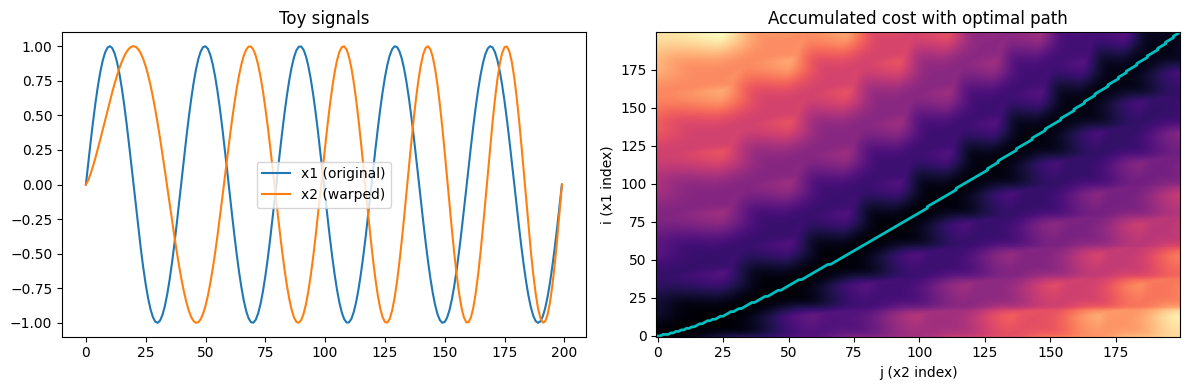

DTW cost (MFCC sequences): 3823.74 | Shapes: X=(69, 20), Y=(69, 20)


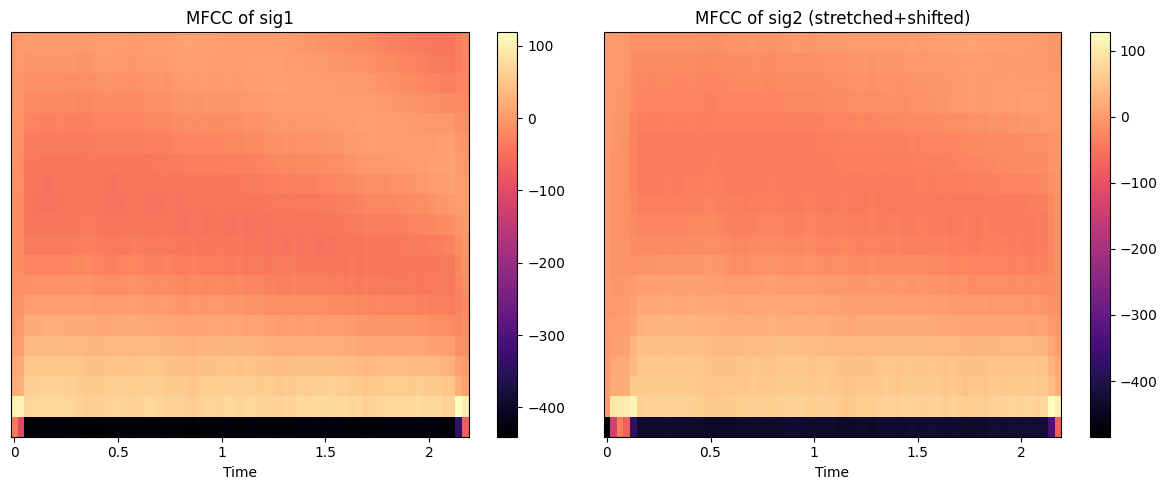

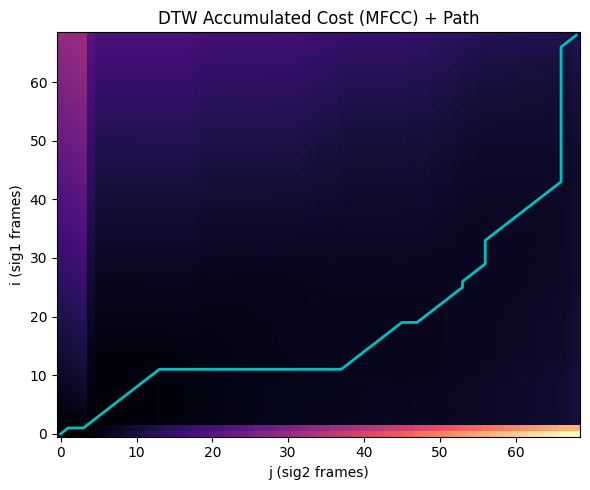

Example mapping (first 15 frames of X -> Y): [ 0  3  4  5  6  7  8  9 10 11 12 37 38 39 40]


In [1]:
!pip -q install numpy scipy librosa matplotlib

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.signal import chirp

# -----------------------------
# DTW (distance + path)
# -----------------------------
def dtw_distance_path(X, Y, dist_fn=None):
    """
    X: [T1, D] or [T1]  (sequence 1)
    Y: [T2, D] or [T2]  (sequence 2)
    Returns:
      cost: total DTW cost (float)
      D: accumulated cost matrix [T1+1, T2+1]
      path: list of (i,j) indices in optimal alignment (0-based)
    """
    X = np.atleast_2d(X)
    if X.shape[0] < X.shape[1]: X = X.T
    Y = np.atleast_2d(Y)
    if Y.shape[0] < Y.shape[1]: Y = Y.T
    T1, D1 = X.shape
    T2, D2 = Y.shape
    assert D1 == D2, "Feature dims must match"

    if dist_fn is None:
        def dist_fn(a,b): return np.linalg.norm(a-b)

    # Accumulated cost matrix with +inf borders
    D = np.full((T1+1, T2+1), np.inf, dtype=np.float64)
    D[0,0] = 0.0

    # Local distance matrix
    for i in range(1, T1+1):
        for j in range(1, T2+1):
            cost = dist_fn(X[i-1], Y[j-1])
            D[i,j] = cost + min(D[i-1,j],    # deletion
                                D[i,j-1],    # insertion
                                D[i-1,j-1])  # match

    # Backtrack optimal path
    i, j = T1, T2
    path = []
    while i>0 or j>0:
        path.append((i-1, j-1))
        if i==0:
            j -= 1
        elif j==0:
            i -= 1
        else:
            steps = np.array([D[i-1,j], D[i,j-1], D[i-1,j-1]])
            arg = steps.argmin()
            if arg==0: i -= 1
            elif arg==1: j -= 1
            else: i -= 1; j -= 1
    path.reverse()
    return D[T1, T2], D, path

# =========================================================
# DEMO 1: 1-D toy signals
# =========================================================
T = 200
t1 = np.linspace(0, 1.0, T)
x1 = np.sin(2*np.pi*5*t1)               # 5Hz sine

# Time-warps: slow start, faster later
t2 = np.linspace(0, 1.0, T)
t2 = t2**1.3                             # nonlinear warp
x2 = np.sin(2*np.pi*5*t2)

# Compute DTW on 1-D (expand dims to [T,1])
cost, D, path = dtw_distance_path(x1[:,None], x2[:,None])

print(f"DTW cost (toy signals): {cost:.4f}")

# Plot signals and alignment path
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x1, label='x1 (original)')
plt.plot(x2, label='x2 (warped)')
plt.title("Toy signals")
plt.legend()

plt.subplot(1,2,2)
plt.imshow(D[1:,1:], origin='lower', aspect='auto', cmap='magma')
pi, pj = zip(*path)
plt.plot(np.array(pj), np.array(pi), 'c-', linewidth=2)  # path overlay
plt.title("Accumulated cost with optimal path")
plt.xlabel("j (x2 index)"); plt.ylabel("i (x1 index)")
plt.tight_layout(); plt.show()

# =========================================================
# DEMO 2: MFCC alignment from synthetic audio
# =========================================================
sr = 16000
dur = 2.2
t = np.linspace(0, dur, int(sr*dur))

# Base synthetic signal: sum of chirps
sig1 = 0.4*chirp(t, f0=180, f1=220, t1=dur, method='linear') \
     + 0.6*chirp(t, f0=300, f1=480, t1=dur, method='quadratic')

# Create a time-stretched + shifted version (explicit misalignment)
stretch = 1.15   # slower
shift   = int(0.07*sr)  # shift right by 70ms
N2 = int(len(sig1)*stretch)
sig2 = np.interp(np.linspace(0, len(sig1)-1, N2), np.arange(len(sig1)), sig1)
sig2 = np.concatenate([np.zeros(shift), sig2])[:len(sig1)]  # same length

# Extract MFCCs
mfcc1 = librosa.feature.mfcc(y=sig1, sr=sr, n_mfcc=20)
mfcc2 = librosa.feature.mfcc(y=sig2, sr=sr, n_mfcc=20)
# Transpose to [T, D]
X = mfcc1.T
Y = mfcc2.T

cost_mfcc, Dm, path_mfcc = dtw_distance_path(X, Y)

print(f"DTW cost (MFCC sequences): {cost_mfcc:.2f} | Shapes: X={X.shape}, Y={Y.shape}")

# Visualize alignment on MFCCs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
librosa.display.specshow(mfcc1, x_axis='time', sr=sr, cmap='magma')
plt.title("MFCC of sig1")
plt.colorbar()
plt.subplot(1,2,2)
librosa.display.specshow(mfcc2, x_axis='time', sr=sr, cmap='magma')
plt.title("MFCC of sig2 (stretched+shifted)")
plt.colorbar()
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
plt.imshow(Dm[1:,1:], origin='lower', aspect='auto', cmap='magma')
pi, pj = zip(*path_mfcc)
plt.plot(np.array(pj), np.array(pi), 'c-', linewidth=2)
plt.title("DTW Accumulated Cost (MFCC) + Path")
plt.xlabel("j (sig2 frames)"); plt.ylabel("i (sig1 frames)")
plt.tight_layout(); plt.show()

# (Optional) Build a frame-wise mapping using the path
# For each frame in X, find the aligned frame in Y
aligned = np.full(X.shape[0], -1, dtype=int)
for (i,j) in path_mfcc:
    aligned[i] = j
print("Example mapping (first 15 frames of X -> Y):", aligned[:15])